In [ ]:
from google.colab import files
uploaded = files.upload()

Saving serie_677_mensal (3).xlsx to serie_677_mensal (3) (2).xlsx


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import ExponentialSmoothing

# Carregar os dados
file_path = 'serie_677_mensal (3).xlsx'
df = pd.read_excel(file_path, parse_dates=['mes_ano'])
df.set_index('mes_ano', inplace=True)

In [ ]:
train_data = df[:'2023']
test_data = df['2024':]

## Prophet

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 19.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp79exz1gl/sublp794.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp79exz1gl/x1p7i3vz.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=68920', 'data', 'file=/tmp/tmp79exz1gl/sublp794.json', 'init=/tmp/tmp79exz1gl/x1p7i3vz.json', 'output', 'file=/tmp/tmp79exz1gl/prophet_modelir6s3ogq/prophet_model-20250316210104.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
21:01:04 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
21:01:04 - cmdstanpy - INFO - Chain [1] done processing
INFO:

Prophet RMSE: 258.5246683162693
Prophet MAE: 227.6197334360047
                 Data  Peso Faturado Real  Peso Faturado Estimado
mes_ano                                                          
2024-01-01 2024-01-01             6314.81             6043.212740
2024-02-01 2024-02-01             7861.18             7453.940239
2024-03-01 2024-03-01             7045.99             7183.044588
2024-04-01 2024-04-01             8208.09             8302.677325


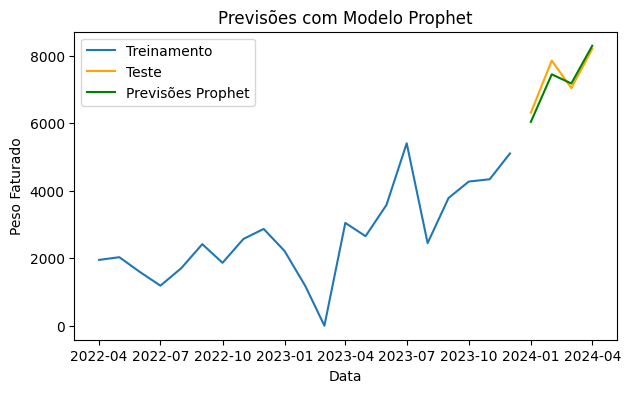

In [ ]:
import pandas as pd
from prophet import Prophet
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# Preparar os dados para Prophet
df_prophet = df.reset_index().rename(columns={'mes_ano': 'ds', 'peso_faturado': 'y'})

# Ajustar o modelo Prophet
prophet_model = Prophet()
prophet_model.fit(df_prophet)

# Fazer previsões
future = prophet_model.make_future_dataframe(periods=len(test_data), freq='M')
prophet_forecast = prophet_model.predict(future)

# Selecionar apenas as previsões para o período de teste
prophet_forecast_test = prophet_forecast.set_index('ds').loc[test_data.index]['yhat']

# Calcular métricas de erro
prophet_rmse = np.sqrt(mean_squared_error(test_data['peso_faturado'], prophet_forecast_test))
prophet_mae = mean_absolute_error(test_data['peso_faturado'], prophet_forecast_test)

print(f'Prophet RMSE: {prophet_rmse}')
print(f'Prophet MAE: {prophet_mae}')

# Criar DataFrame com valores reais e estimados
results_df = pd.DataFrame({
    'Data': test_data.index,
    'Peso Faturado Real': test_data['peso_faturado'],
    'Peso Faturado Estimado': prophet_forecast_test.values
})

# Exibir a tabela
print(results_df)

# Plotar os resultados
plt.figure(figsize=(7, 4))
plt.plot(train_data.index, train_data['peso_faturado'], label='Treinamento')
plt.plot(test_data.index, test_data['peso_faturado'], label='Teste', color='orange')
plt.plot(test_data.index, prophet_forecast_test.values, label='Previsões Prophet', color='green')
plt.title('Previsões com Modelo Prophet')
plt.xlabel('Data')
plt.ylabel('Peso Faturado')
plt.legend()
plt.show()


In [ ]:
# Criar DataFrame com valores reais e estimados
results_df = pd.DataFrame({
    'Data': test_data.index,
    'Peso Faturado Real': test_data['peso_faturado'],
    'Peso Faturado Estimado': prophet_forecast_test
})

# Exibir a tabela
print(results_df)

                 Data  Peso Faturado Real  Peso Faturado Estimado
mes_ano                                                          
2024-01-01 2024-01-01             6314.81             6043.212740
2024-02-01 2024-02-01             7861.18             7453.940239
2024-03-01 2024-03-01             7045.99             7183.044588
2024-04-01 2024-04-01             8208.09             8302.677325


## Modelo de Dimensionamento de Estoque

Modelo de Dimensionamento de Estoque

In [ ]:
# Carregar os dados do primeiro conjunto
file_path = 'serie_677_mensal (3).xlsx'
df = pd.read_excel(file_path, parse_dates=['mes_ano'])
df.set_index('mes_ano', inplace=True)

# Dados fornecidos (estoque)
data = {
    'Data': ['01/01/2022', '01/02/2022', '01/03/2022', '01/04/2022', '01/05/2022', '01/06/2022', '01/07/2022', '01/08/2022',
             '01/09/2022', '01/10/2022', '01/11/2022', '01/12/2022', '01/01/2023', '01/02/2023', '01/03/2023', '01/04/2023',
             '01/05/2023', '01/06/2023', '01/07/2023', '01/08/2023', '01/09/2023', '01/10/2023', '01/11/2023', '01/12/2023'],
    'Estoque_kg': [1213, 1280, 1347, 1213, 1280, 1347, 1213, 1280, 1347, 1482, 1549, 1617, 1906, 2011, 2117, 1906, 2011, 2117, 1906,
                   2011, 2117, 2329, 2435, 2541],
    'Preco_medio': [19, 20, 17, 22, 21, 21, 22, 23, 23, 24, 24, 25, 25, 26, 26, 27, 27, 28, 29, 29, 30, 30, 31, 31]
}

# Criar DataFrame do estoque
df_estoque = pd.DataFrame(data)
df_estoque['Data'] = pd.to_datetime(df_estoque['Data'], format='%d/%m/%Y')
df_estoque.set_index('Data', inplace=True)

# Aqui, vamos garantir que ambos os DataFrames têm o mesmo índice de data
df_combined = df.join(df_estoque, how='outer', lsuffix='_faturado', rsuffix='_estoque')

# Calcular o tempo de reposição
df_combined['tempo_reposicao'] = df_combined['Estoque_kg'] / df_combined['qtd_faturada'].replace(0, np.nan)

# Resetar o índice para transformar a data em uma coluna
df_combined_reset = df_combined.reset_index()

# Renomear a coluna de índice para 'Data'
df_combined_reset.rename(columns={'index': 'mes_ano'}, inplace=True)

# Exibir o DataFrame resultante
print(df_combined_reset[['mes_ano', 'peso_faturado', 'Estoque_kg', 'tempo_reposicao']])

      mes_ano  peso_faturado  Estoque_kg  tempo_reposicao
0  2022-01-01            NaN      1213.0              NaN
1  2022-02-01            NaN      1280.0              NaN
2  2022-03-01            NaN      1347.0              NaN
3  2022-04-01     1951.98000      1213.0        68.016149
4  2022-05-01     2032.12500      1280.0      -225.590412
5  2022-06-01     1587.43676      1347.0        13.806747
6  2022-07-01     1187.71800      1213.0         8.084295
7  2022-08-01     1709.21800      1280.0         4.962029
8  2022-09-01     2418.42100      1347.0         6.068770
9  2022-10-01     1865.49700      1482.0         2.454744
10 2022-11-01     2573.11200      1549.0         4.454490
11 2022-12-01     2869.72900      1617.0         9.120958
12 2023-01-01     2215.26300      1906.0         9.549146
13 2023-02-01     1167.08900      2011.0        12.109060
14 2023-03-01        0.00000      2117.0              NaN
15 2023-04-01     3048.33500      1906.0         5.518527
16 2023-05-01 

In [ ]:
# Calcular o estoque de segurança
Z = 1.95

alpha_demanda = df_combined['peso_faturado'].mean()

# Adicionar a previsão de demanda ao DataFrame combinado
df_combined['demanda_prevista'] = prophet_forecast_test

# Calcular o estoque de segurança incluindo a previsão de demanda
df_combined['estoque_seguranca'] = df_combined['demanda_prevista'] + (Z * alpha_demanda) * np.sqrt((df_combined['tempo_reposicao']).fillna(0))

# Calcular o estoque necessário
df_combined['estoque_necessario'] = alpha_demanda   + df_combined['estoque_seguranca']


/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
df_combined['estoque_seguranca'] = df_combined['estoque_seguranca'].fillna(0)
df_combined['estoque_seguranca'] = df_combined['estoque_seguranca'].replace([np.inf, -np.inf], 0)

## Modelo 1

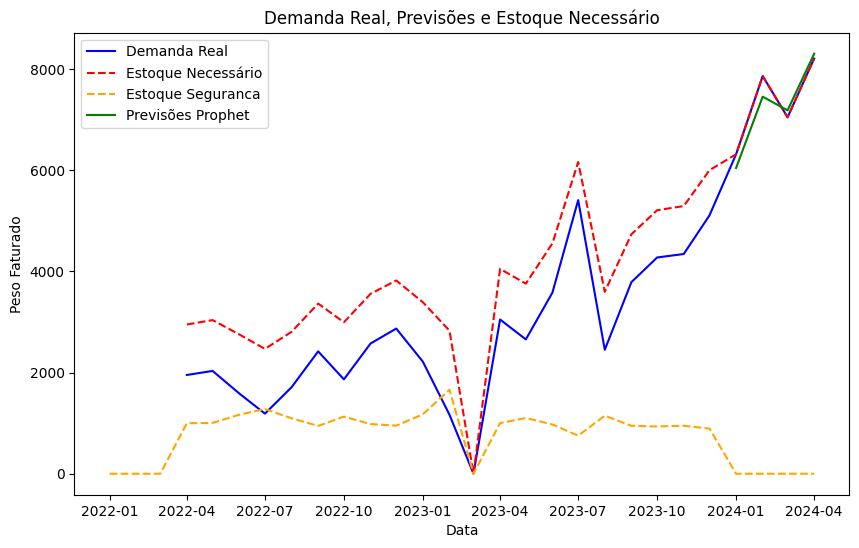

In [ ]:
# Calcular o tempo de reposição
df_combined['tempo_reposicao'] = df_combined['Estoque_kg'] / df_combined['peso_faturado'].replace(0, np.nan)

# Calcular o estoque de segurança
Z = 1.95
alpha_demanda = df_combined['peso_faturado'].std()

df_combined['estoque_seguranca'] = Z * 0.3 * alpha_demanda * np.sqrt(df_combined['tempo_reposicao'].fillna(0))

# Calcular o estoque necessário
df_combined['estoque_necessario'] = df_combined['peso_faturado'] + df_combined['estoque_seguranca']

# Plotar os resultados
plt.figure(figsize=(10, 6))
plt.plot(df_combined.index, df_combined['peso_faturado'], label='Demanda Real', color='blue')
plt.plot(df_combined.index, df_combined['estoque_necessario'], label='Estoque Necessário', color='red', linestyle='--')
plt.plot(df_combined.index, df_combined['estoque_seguranca'], label='Estoque Seguranca', color='orange', linestyle='--')
plt.plot(test_data.index, prophet_forecast_test.values, label='Previsões Prophet', color='green')
plt.title('Demanda Real, Previsões e Estoque Necessário')
plt.xlabel('Data')
plt.ylabel('Peso Faturado')
plt.legend()
plt.show()

## Modelo 2

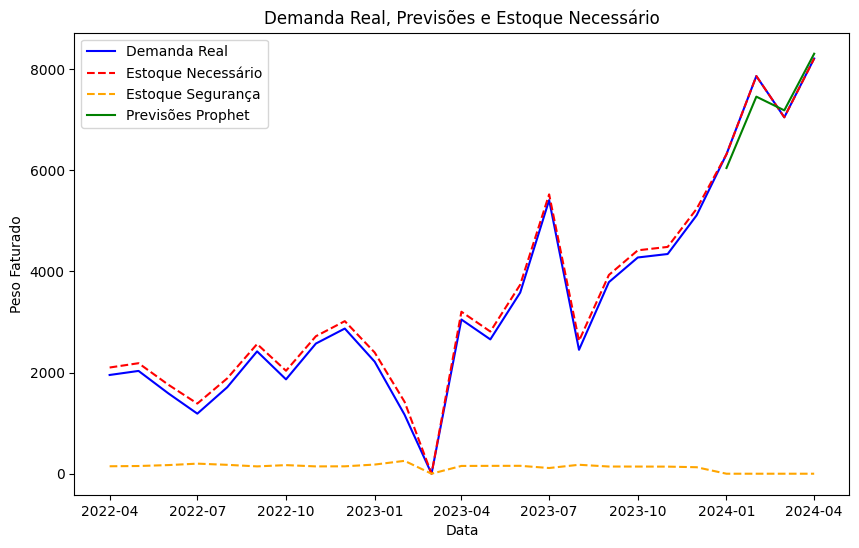

In [ ]:
# Calcular o desvio padrão da previsão do Prophet
Z = 1.96
prophet_forecast['sigma_previsao'] = (prophet_forecast['yhat_upper'] - prophet_forecast['yhat_lower']) / (2 * Z)

# Adicionar o desvio padrão da previsão ao DataFrame combinado
df_combined = df_combined.join(
    prophet_forecast.set_index('ds')[['sigma_previsao']],
    how='left',
    rsuffix='_prophet'
)

# Calcular o estoque de segurança usando o desvio padrão da previsão
df_combined['estoque_seguranca'] = Z * 0.8 * df_combined['sigma_previsao'] * np.sqrt(df_combined['tempo_reposicao'].fillna(0))

# Calcular o estoque necessário
df_combined['estoque_necessario'] = df_combined['peso_faturado'] + df_combined['estoque_seguranca']

# Plotar os resultados
plt.figure(figsize=(10, 6))
plt.plot(df_combined.index, df_combined['peso_faturado'], label='Demanda Real', color='blue')
plt.plot(df_combined.index, df_combined['estoque_necessario'], label='Estoque Necessário', color='red', linestyle='--')
plt.plot(df_combined.index, df_combined['estoque_seguranca'], label='Estoque Segurança', color='orange', linestyle='--')
plt.plot(test_data.index, prophet_forecast_test.values, label='Previsões Prophet', color='green')
plt.title('Demanda Real, Previsões e Estoque Necessário')
plt.xlabel('Data')
plt.ylabel('Peso Faturado')
plt.legend()
plt.show()

In [ ]:
# Calcular o erro absoluto percentual (APE)
df_combined['ape'] = abs(df_combined['peso_faturado'] - df_combined['demanda_prevista']) / df_combined['peso_faturado'].replace(0, np.nan)

# Calcular o WMAPE
wmape = (df_combined['ape'] * df_combined['peso_faturado']).sum() / df_combined['peso_faturado'].sum()

print(f"WMAPE: {wmape:.2%}")


WMAPE: 1.06%


Otimizar constante

A melhor constante encontrada (busca em grade) é: 0.2
Menor erro (MSE) encontrado: 9.57452900040147


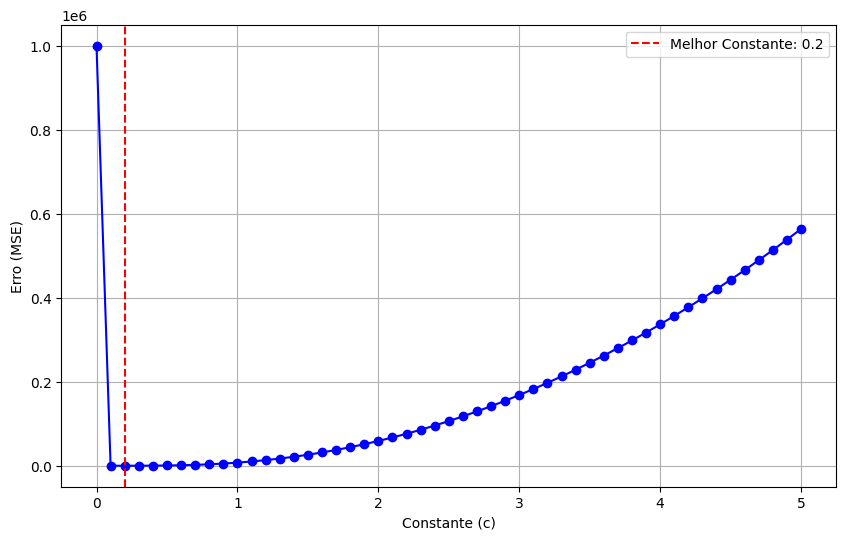

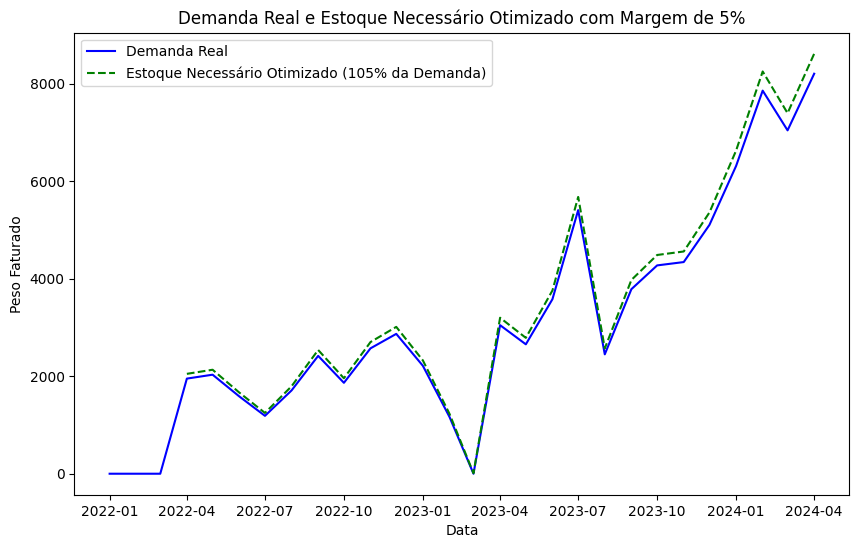

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Função para calcular o estoque de segurança com uma constante personalizada
def calcular_estoque_seguranca(df_combined, constante, Z=1.96, limiar_minimo=10):
    estoque_seguranca = Z * constante * df_combined['sigma_previsao'] * np.sqrt(df_combined['tempo_reposicao'].fillna(0))
    return np.maximum(estoque_seguranca, limiar_minimo)  # Garantir um valor mínimo para o estoque de segurança

# Função para calcular o erro (MSE) entre o estoque necessário otimizado e 105% da demanda real
def erro_estoque_seguranca(df_combined, constante, margem_percentual=0.05, lambda_penalidade=1, lambda_custo_falta=100, epsilon=1e-6):
    # Calculando o estoque de segurança otimizado com a constante fornecida
    df_combined['estoque_seguranca_otimizado'] = calcular_estoque_seguranca(df_combined, constante)

    # Calculando o estoque necessário otimizado (peso_faturado + estoque_seguranca_otimizado)
    df_combined['estoque_necessario_otimizado'] = (
        df_combined['peso_faturado'] + df_combined['estoque_seguranca_otimizado']
    )

    # Garantir que o estoque necessário esteja sempre a 105% da demanda real
    df_combined['estoque_necessario_otimizado'] = np.maximum(
        df_combined['estoque_necessario_otimizado'], df_combined['peso_faturado'] * (1 + margem_percentual)
    )

    # Substituindo NaN por 0 (sem usar inplace=True)
    df_combined['estoque_necessario_otimizado'] = df_combined['estoque_necessario_otimizado'].fillna(0)
    df_combined['peso_faturado'] = df_combined['peso_faturado'].fillna(0)

    # Calculando o MSE entre 105% da demanda real e o estoque necessário otimizado
    mse = mean_squared_error(df_combined['peso_faturado'] * (1 + margem_percentual), df_combined['estoque_necessario_otimizado'])

    # Penalização para constantes muito baixas
    penalidade_constante = lambda_penalidade / (constante + epsilon)

    # Custo de falta de estoque (quando o estoque necessário é menor que a demanda real)
    custo_falta = np.sum(df_combined['estoque_necessario_otimizado'] < df_combined['peso_faturado'])

    # Retornar o erro total (MSE + penalização da constante + custo de falta)
    return mse + penalidade_constante + lambda_custo_falta * custo_falta

# Função para realizar a busca em grade e encontrar a melhor constante
def buscar_melhor_constante(df_combined, margem_percentual=0.05, constante_min=0.5, constante_max=5, passo=0.1):
    # Gerar valores da constante no intervalo especificado
    constantes = np.arange(constante_min, constante_max + passo, passo)

    # Calcular o erro para cada valor da constante
    erros = [erro_estoque_seguranca(df_combined, c, margem_percentual) for c in constantes]

    # Encontrar a constante com o menor erro
    melhor_constante = constantes[np.argmin(erros)]
    menor_erro = np.min(erros)

    return melhor_constante, menor_erro, constantes, erros

# Definir a margem percentual (5%)
margem_percentual = 0.05

# Realizar a busca em grade para encontrar a melhor constante
melhor_constante, menor_erro, constantes, erros = buscar_melhor_constante(df_combined, margem_percentual, constante_min=0, constante_max=5, passo=0.1)

# Exibir a melhor constante encontrada
print(f"A melhor constante encontrada (busca em grade) é: {melhor_constante}")
print(f"Menor erro (MSE) encontrado: {menor_erro}")

# Plotar o erro em função da constante
plt.figure(figsize=(10, 6))
plt.plot(constantes, erros, marker='o', linestyle='-', color='b')
# plt.title('Erro (MSE) em Função da Constante')
plt.xlabel('Constante (c)')
plt.ylabel('Erro (MSE)')
plt.axvline(x=melhor_constante, color='r', linestyle='--', label=f'Melhor Constante: {melhor_constante}')
plt.legend()
plt.grid(True)
plt.show()

# Calcular o estoque de segurança com a constante otimizada
df_combined['estoque_seguranca_otimizado'] = calcular_estoque_seguranca(df_combined, melhor_constante)

# Calcular o estoque necessário otimizado
df_combined['estoque_necessario_otimizado'] = (
    df_combined['peso_faturado'] + df_combined['estoque_seguranca_otimizado']
)

# Garantir que o estoque necessário esteja sempre a 105% da demanda real
df_combined['estoque_necessario_otimizado'] = np.maximum(
    df_combined['estoque_necessario_otimizado'], df_combined['peso_faturado'] * (1 + margem_percentual)
)

# Plotar os resultados
plt.figure(figsize=(10, 6))
plt.plot(df_combined.index, df_combined['peso_faturado'], label='Demanda Real', color='blue')
plt.plot(df_combined.index, df_combined['estoque_necessario_otimizado'], label='Estoque Necessário Otimizado (105% da Demanda)', color='green', linestyle='--')
plt.title('Demanda Real e Estoque Necessário Otimizado com Margem de 5%')
plt.xlabel('Data')
plt.ylabel('Peso Faturado')
plt.legend()
plt.show()

RMSE

In [ ]:
# Criar cópia com dados válidos apenas
df_valid = df_combined[['peso_faturado', 'estoque_necessario_otimizado']].dropna()

# Calcular RMSE
rmse = np.sqrt(mean_squared_error(df_valid['peso_faturado'] * (1 + margem_percentual),
                                  df_valid['estoque_necessario_otimizado']))
print(f'RMSE do estoque necessário otimizado: {rmse:.2f}')


RMSE do estoque necessário otimizado: 2.26


R^2

In [ ]:
from sklearn.metrics import r2_score

# Supondo que você está comparando com 105% da demanda
referencia = df_valid['peso_faturado'] * 1.05
predito = df_valid['estoque_necessario_otimizado']

# Calcular R²
r2 = r2_score(referencia, predito)
print(f'R²: {r2:.4f}')



R²: 1.0000


Coeficiente de variação ponderado

In [ ]:
valores = df_combined['peso_faturado']
pesos = df_combined['Estoque_kg']

# Remover NaNs
mascara = valores.notna() & pesos.notna() & (pesos > 0)
valores = valores[mascara]
pesos = pesos[mascara]

# Verifica se existe peso positivo e média diferente de zero
if pesos.sum() > 0 and np.average(valores, weights=pesos) != 0:
    media_ponderada = np.average(valores, weights=pesos)
    variancia_ponderada = np.average((valores - media_ponderada)**2, weights=pesos)
    desvio_padrao_ponderado = np.sqrt(variancia_ponderada)
    cv_ponderado = (desvio_padrao_ponderado / media_ponderada) * 100
    print(f'Coeficiente de Variação Ponderado: {cv_ponderado:.2f}%')
else:
    print("Não foi possível calcular: pesos zerados ou média nula.")


Coeficiente de Variação Ponderado: 60.54%
